In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
import keras
from keras.models import Model
from keras.layers import Dense, Input, Conv2D, MaxPooling2D, Flatten
from keras.optimizers import Adam
from keras.losses import binary_crossentropy

In [5]:
# Parse the .sums file to extract metadata
def parse_sums_file(sums_file):
    file_info_list = []
    with open(sums_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 2:
                file_info_list.append(parts)
            else:
                print(f"Skipping invalid line in .sums file: {line}")
    return file_info_list

In [6]:
# Load image and label using the correct path
def load_image_and_label(file_info, base_dir, img_size=(100, 100)):
    image_path = file_info[1]
    image_path = image_path.replace("data/", "")
    full_image_path = os.path.join(base_dir, image_path)
    print(f"Loading image from path: {full_image_path}")

    # skips missing images if they exist in the .sums file but not in the directory
    if not os.path.exists(full_image_path):
        print(f"Skipping missing image: {image_path}")
        return None, None

    # preprocess the image: resize, convert to grayscale, and normalize pixel values
    try:
        img = Image.open(full_image_path)
        img = img.resize(img_size)
        img = img.convert("L")
        img_array = np.array(img) / 255.0
        category = os.path.basename(os.path.dirname(os.path.dirname(image_path)))

        label = category
        return img_array, label

    except Exception as e:
        print(f"Error loading image at {full_image_path}: {e}")
        return None, None



In [7]:
sums_file = "AML-Cytomorphology_MLL_Helmholtz_v1.sums"
base_dir = "data"

if not os.path.exists(base_dir):
    raise FileNotFoundError(f"The base directory does not exist: {base_dir}")


file_info_list = parse_sums_file(sums_file)

images = []
labels = []

for file_info in file_info_list[:500]:
    img, label = load_image_and_label(file_info, base_dir)
    if img is not None:
        images.append(img)
        labels.append(label)


print(f"Successfully loaded {len(images)} images.")

Loading image from path: data/RUNX1_RUNX1T1/KRG/image_276.tif
Loading image from path: data/CBFB_MYH11/FPW/image_219.tif
Loading image from path: data/control/MPP/image_149.tif
Loading image from path: data/control/DPU/image_192.tif
Loading image from path: data/PML_RARA/CWF/image_72.tif
Loading image from path: data/CBFB_MYH11/FKU/image_360.tif
Loading image from path: data/NPM1/CVW/image_421.tif
Loading image from path: data/NPM1/OCV/image_175.tif
Loading image from path: data/control/GJQ/image_389.tif
Loading image from path: data/RUNX1_RUNX1T1/DHA/image_119.tif
Loading image from path: data/control/XXJ/image_249.tif
Loading image from path: data/NPM1/NHB/image_375.tif
Loading image from path: data/RUNX1_RUNX1T1/ABF/image_437.tif
Loading image from path: data/control/DJJ/image_65.tif
Loading image from path: data/control/TBZ/image_273.tif
Loading image from path: data/RUNX1_RUNX1T1/ONF/image_105.tif
Loading image from path: data/CBFB_MYH11/GOR/image_40.tif
Loading image from path: d

In [8]:
# Convert lists to numpy arrays and encode labels
x_data = np.array(images)
label_map = {label: idx for idx, label in enumerate(set(labels))}
y_data = np.array([label_map[label] for label in labels])

# Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(
    x_data, y_data, test_size=0.25, random_state=42
)

# identify the number of rows and columns in the images for reshaping
img_rows, img_cols = x_train.shape[1], x_train.shape[2]

# reshapes data to fit the input shape of the CNN (number of samples, rows, cols, channels)
x_train = x_train.reshape(-1, img_rows, img_cols, 1)
x_test = x_test.reshape(-1, img_rows, img_cols, 1)

In [9]:
# builds a CNN model with two convolutional layers, max pooling, and fully connected layers for classification
inpx = Input(shape=(img_rows, img_cols, 1))
conv_layer = Conv2D(32, (3,3), activation='relu', padding='same')(inpx)
pool_layer = MaxPooling2D((3,3))(conv_layer)
# added a second convolutional layer to increase the model's capacity 
# to learn more complex features from the images, which can improve classification performance
second_conv_layer = Conv2D(64, (3,3), activation='relu', padding='same')(pool_layer)
second_pool_layer = MaxPooling2D((2,2))(second_conv_layer)
# flattens to convert the 2D feature maps into a 1D vector
flat_G = Flatten()(second_pool_layer)
# added first hidden layer with 128 neurons and 'relu' activation to allow model complexity
hid_layer = Dense(128, activation='relu')(flat_G)
# added a second hidden layer with 64 neurons and 'tanh' activation to allow model complexity
hid_layer2 = Dense(64, activation='tanh')(hid_layer)
# output layer with softmax activation for multi-class classification, where the number of neurons corresponds to the number of unique labels
# we do this because AML has multiple subtypes, so we need to classify into more than two categories (unlike binary), and softmax allows us to get probabilities for each class
out_layer = Dense(len(label_map), activation='softmax')(hid_layer2)
model = Model([inpx], out_layer)

# compiles the model using the Adam optimizer for less cross-entropy loss and tracks accuracy as a metric 
model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [10]:
# fits the model to training data for 10 epochs
# model will learn from data and adjust weights to minimize loss, with batch size of 64 for efficient training
model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    verbose=1
)


Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 264ms/step - accuracy: 0.1709 - loss: 1.6800
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 199ms/step - accuracy: 0.2213 - loss: 1.5973
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 256ms/step - accuracy: 0.3375 - loss: 1.5689
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 308ms/step - accuracy: 0.3387 - loss: 1.5415
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 248ms/step - accuracy: 0.4298 - loss: 1.4831
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 218ms/step - accuracy: 0.3097 - loss: 1.4936
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 212ms/step - accuracy: 0.4199 - loss: 1.4130
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step - accuracy: 0.4450 - loss: 1.4068
Epoch 9/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 230ms/step - accuracy: 0.4595 - loss: 1.3709
Epoch 10/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 245ms/step - accuracy: 0.4195 - loss: 1.3638


In [11]:

# prints test accuracy of the model on unseen data to evaluate performance and generalization capability
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test accuracy: {accuracy * 100:.2f}%")


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3941 - loss: 1.5146
Test accuracy: 36.80%


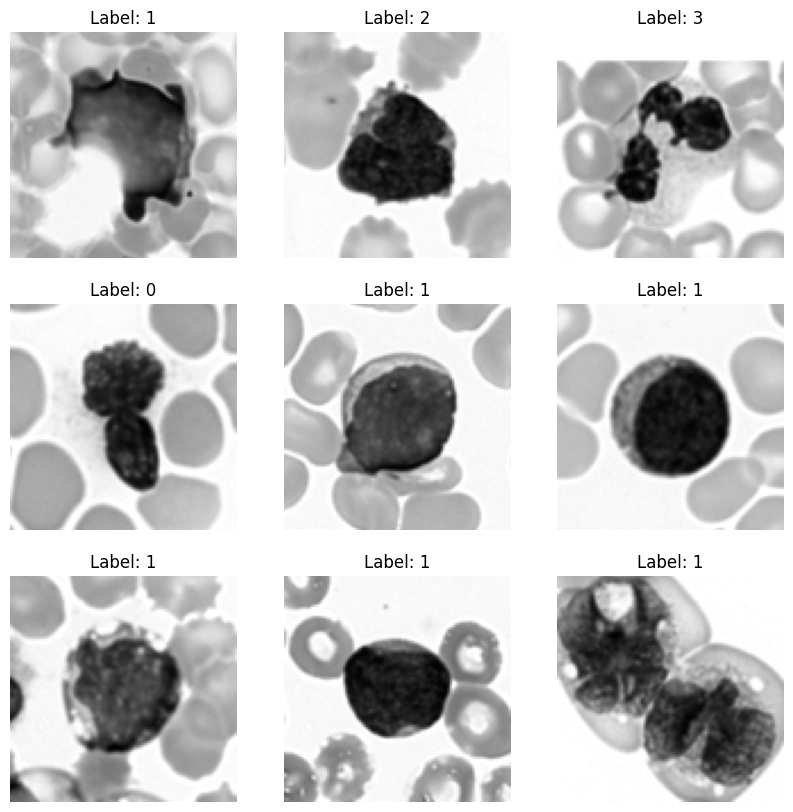

In [12]:

# visualizes the first 9 images from the test set along with their true labels 
# to qualitatively assess the model's performance and understand the data distribution
plt.figure(figsize=(10,10))

# (i.e. we can see if the model is correctly classifying different subtypes of AML by looking at the images and their corresponding labels, 
# which can help identify any patterns or misclassifications in the data)
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_test[i].reshape(img_rows,img_cols), cmap='gray')
    plt.title(f"Label: {y_test[i]}")
    plt.axis('off')

plt.show()